# 🎙️ Fine-Tuning OpenAI Whisper for Speech & Language Processing (SLP)
### **Project: VoiceDrop-2.0 Telephony & Delivery Dialogue Adaptation**

This notebook demonstrates the complete **Speech & Language Processing (SLP)** pipeline:
1. **Acoustic Front-End**: 80-channel Log-Mel Filterbank extraction from 16kHz audio.
2. **Tokenization**: Byte-Pair Encoding (BPE) subword token representation.
3. **Parameter-Efficient Fine-Tuning (PEFT)**: Low-Rank Adaptation (LoRA: $W = W_0 + \\frac{\\alpha}{r}BA$) on Whisper's Transformer attention layers.
4. **Evaluation**: Word Error Rate (WER) + Character Error Rate (CER) computation and benchmark comparison.

> 💡 *Tip*: In Google Colab, go to **Runtime > Change runtime type > Hardware accelerator > T4 GPU** before running.

---
## ⚙️ Step 0: Configuration — Edit All Hyperparameters Here
All tunable knobs are in one place so you never need to hunt through the notebook.

In [ ]:
# ============================================================
# 🛠️  CONFIGURATION BLOCK — tune all parameters here
# ============================================================

# --- Model ---
MODEL_NAME     = "openai/whisper-tiny"   # or 'openai/whisper-small' / 'openai/whisper-base'
LANGUAGE       = "english"               # lowercase — WhisperTokenizer's LANGUAGES dict uses lowercase keys
TASK           = "transcribe"

# --- Dataset ---
DATASET_NAME   = "google/fleurs"
DATASET_CONFIG = "en_us"                 # FLEURS uses 'en_us'; 'en_in' does not exist
NUM_TRAIN      = 1000                    # samples to use for training
NUM_EVAL       = 200                     # samples to use for evaluation

# --- LoRA ---
LORA_R         = 16                      # rank of update matrices
LORA_ALPHA     = 32                      # scaling factor (effective lr scale = alpha/r)
LORA_DROPOUT   = 0.05
LORA_TARGETS   = ["q_proj", "v_proj", "k_proj", "out_proj"]  # 4 projections for richer adaptation

# --- Training ---
OUTPUT_DIR     = "./whisper_lora_model"
SAVE_DIR       = "./whisper_finetuned_delivery"
NUM_EPOCHS     = 3
TRAIN_BATCH    = 8
EVAL_BATCH     = 8
GRAD_ACCUM     = 2                       # effective batch = TRAIN_BATCH * GRAD_ACCUM = 16
LEARNING_RATE  = 1e-3
WARMUP_STEPS   = 50
LR_SCHEDULER   = "cosine"               # 'linear' | 'cosine' | 'cosine_with_restarts'
GEN_MAX_LEN    = 128
LOGGING_STEPS  = 25
SAVE_TOTAL     = 2                       # keep only the 2 best checkpoints

print(f"✅ Config ready: {MODEL_NAME} | LoRA r={LORA_R} α={LORA_ALPHA} | "
      f"{NUM_EPOCHS} epochs | {NUM_TRAIN} train / {NUM_EVAL} eval samples")

✅ Config ready: openai/whisper-tiny | LoRA r=16 α=32 | 3 epochs | 1000 train / 200 eval samples


---
## 📦 Step 1: Install Required Libraries

In [ ]:
# transformers>=4.46 required for `processing_class` argument in Seq2SeqTrainer
%pip install -q \
    "torch>=2.0.0" \
    "transformers>=4.46.0" \
    "datasets>=2.18.0" \
    evaluate \
    "jiwer>=3.0.0" \
    peft \
    accelerate \
    soundfile \
    librosa \
    matplotlib \
    "torchao>=0.16.0"

---
## 🔬 Step 2: Import Dependencies & Check GPU

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from datasets import load_dataset, Audio, Dataset
from transformers import (
    WhisperFeatureExtractor,
    WhisperTokenizer,
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from peft import LoraConfig, inject_adapter_in_model

try:
    import evaluate
    wer_metric = evaluate.load("wer")
    cer_metric = evaluate.load("cer")
except Exception:
    wer_metric = None
    cer_metric = None

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device : {device}")

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"   GPU    : {props.name}")
    print(f"   VRAM   : {props.total_memory / 1024**3:.1f} GB")

print(f"✅ PyTorch : {torch.__version__}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


✅ Device : cuda
   GPU    : Tesla T4
   VRAM   : 14.6 GB
✅ PyTorch : 2.11.0+cu130


---
## 🎚️ Step 3: Load Acoustic Feature Extractor & Tokenizer
- `WhisperFeatureExtractor`: Converts raw 16 kHz audio waveforms into **80-channel Log-Mel Spectrograms** (25 ms window, 10 ms hop).
- `WhisperTokenizer`: Encodes transcription text into subword token IDs using **Byte-Pair Encoding (BPE)**.

> `clean_up_tokenization_spaces=False` is set explicitly to suppress the BPE tokenization warning — post-processing whitespace cleanup is designed for WordPiece, not BPE, and would corrupt Whisper's output.

In [ ]:
print(f"Loading feature extractor and tokenizer for {MODEL_NAME}...")

feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)

# language must be lowercase — WhisperTokenizer's internal LANGUAGES dict uses all-lowercase keys.
# clean_up_tokenization_spaces=False: suppresses the BPE tokenizer warning; post-processing
# whitespace cleanup is designed for WordPiece and is destructive for BPE.
tokenizer = WhisperTokenizer.from_pretrained(
    MODEL_NAME,
    language=LANGUAGE,
    task=TASK,
    clean_up_tokenization_spaces=False,
)
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language=LANGUAGE,
    task=TASK,
)
# Patch tokenizer inside processor as well
processor.tokenizer.clean_up_tokenization_spaces = False

print(f"   Sampling rate : {feature_extractor.sampling_rate} Hz")
print(f"   Mel channels  : {feature_extractor.feature_size}")
print(f"   Vocab size    : {tokenizer.vocab_size:,}")
print("✅ Feature extractor, tokenizer, and processor loaded successfully.")

Loading feature extractor and tokenizer for openai/whisper-tiny...
   Sampling rate : 16000 Hz
   Mel channels  : 80
   Vocab size    : 50,258
✅ Feature extractor, tokenizer, and processor loaded successfully.


---
## 📂 Step 4: Load & Prepare Dataset
We load `google/fleurs` with the `en_us` subset (American English), with automatic fallback to synthetic Indian English telephony samples if offline.

> **Note**: `en_in` does not exist in the FLEURS dataset. The closest available English variant is `en_us`.

In [ ]:
print(f"Loading speech dataset ({DATASET_NAME} / {DATASET_CONFIG})...")
try:
    dataset = load_dataset(DATASET_NAME, DATASET_CONFIG)
    dataset = dataset.cast_column("audio", Audio(sampling_rate=feature_extractor.sampling_rate))
    train_raw = dataset["train"]
    eval_raw  = dataset.get("validation", dataset.get("test"))
    print(f"✅ Loaded {DATASET_NAME} ({DATASET_CONFIG}): "
          f"{len(train_raw)} train samples, {len(eval_raw)} eval samples.")
except Exception as e:
    print(f"⚠️ Could not download {DATASET_NAME} ({e}).\n"
          "Creating synthetic Indian English delivery benchmark dataset...")
    delivery_phrases = [
        "Please leave the parcel with the security guard at gate number two.",
        "Your OTP for Flipkart delivery is four eight two zero.",
        "I am waiting near tower B flat four hundred and two.",
        "Please deliver the order tomorrow afternoon after two pm.",
        "Keep the package at the doorstep, no one is home right now.",
        "Your Swiggy order is arriving in five minutes please be available.",
        "Please do not ring the doorbell, baby is sleeping.",
        "Call me when you reach the main entrance gate.",
    ]
    t = np.linspace(0, 3.0, int(feature_extractor.sampling_rate * 3.0), dtype=np.float32)
    synth_data = [
        {
            "audio": {
                "array": (0.2 * np.sin(2 * np.pi * 220 * t) + 0.1 * np.sin(2 * np.pi * 440 * t)).astype(np.float32),
                "sampling_rate": feature_extractor.sampling_rate,
            },
            "transcription": p,
        }
        for p in delivery_phrases
    ]
    train_raw = Dataset.from_list(synth_data * 15)
    eval_raw  = Dataset.from_list(synth_data * 3)


def prepare_dataset(batch):
    """Waveform → 80-channel Log-Mel Spectrogram → BPE Token IDs."""
    audio = batch["audio"]
    # Compute 80-channel Log-Mel spectrogram (sampling_rate=16000)
    batch["input_features"] = feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
    ).input_features[0]
    # Tokenize target text; try all common transcript field names
    transcript = str(
        batch.get("transcription")
        or batch.get("raw_transcription")
        or batch.get("sentence")
        or ""
    )
    batch["labels"] = tokenizer(transcript).input_ids
    return batch


# Clamp to configured subset sizes
num_train = min(len(train_raw), NUM_TRAIN)
num_eval  = min(len(eval_raw),  NUM_EVAL)

print(f"Preprocessing {num_train} train + {num_eval} eval samples…")
train_data = train_raw.select(range(num_train)).map(
    prepare_dataset, remove_columns=train_raw.column_names, num_proc=1
)
eval_data = eval_raw.select(range(num_eval)).map(
    prepare_dataset, remove_columns=eval_raw.column_names, num_proc=1
)

# Quick sanity: show mean audio duration from a few samples
sample_durations = [
    len(train_raw[i]["audio"]["array"]) / feature_extractor.sampling_rate
    for i in range(min(20, num_train))
]
print(f"   Mean audio duration (first 20 samples): {np.mean(sample_durations):.1f}s")
print(f"✅ Preprocessed {len(train_data)} train samples and {len(eval_data)} eval samples.")

Loading speech dataset (google/fleurs / en_us)...
✅ Loaded google/fleurs (en_us): 2602 train samples, 394 eval samples.
Preprocessing 1000 train + 200 eval samples…
   Mean audio duration (first 20 samples): 9.8s
✅ Preprocessed 1000 train samples and 200 eval samples.


---
## 🔧 Step 5: Configure LoRA (Parameter-Efficient Fine-Tuning)
Instead of updating all ~39M parameters of Whisper-tiny, LoRA inserts **low-rank decomposition matrices** ($r=16$) onto four attention projections (`q_proj`, `v_proj`, `k_proj`, `out_proj`), training only **~1.2%** of total weights.

$$W_{\text{adapted}} = W_0 + \frac{\alpha}{r} \cdot B \cdot A \quad (A \in \mathbb{R}^{r \times d_{\text{in}}},\ B \in \mathbb{R}^{d_{\text{out}} \times r})$$

> **Implementation note**: We use `inject_adapter_in_model` (lower-level PEFT API) instead of `get_peft_model`.
> In recent PEFT versions, `PeftModelForSeq2SeqLM.forward()` passes `input_ids` as a keyword argument
> which conflicts with Whisper's decoder receiving it positionally, causing
> `TypeError: got multiple values for keyword argument 'input_ids'`.
> By injecting the adapter directly into the base model we keep the original Whisper `forward()` intact.

In [ ]:
from peft import LoraConfig, get_peft_model
import peft
import torch

print(f"Loading {MODEL_NAME} for LoRA adaptation...")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

model.config.forced_decoder_ids = None
model.config.suppress_tokens     = []
model.config.use_cache           = False
if hasattr(model, "generation_config"):
    model.generation_config.language          = LANGUAGE
    model.generation_config.task              = TASK
    model.generation_config.forced_decoder_ids = None

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
)

# 1. FIX: Dummy method for Transformers 4.46+
def _dummy_kwargs(self, *args, **kwargs):
    return kwargs.get("model_kwargs", kwargs)
setattr(WhisperForConditionalGeneration, "_prepare_encoder_decoder_kwargs_for_generation", _dummy_kwargs)
try:
    setattr(peft.tuners.lora.model.LoraModel, "_prepare_encoder_decoder_kwargs_for_generation", _dummy_kwargs)
except AttributeError:
    pass

# 2. FIX: Protect forward AND generate from unexpected kwargs pushed by PEFT/Trainer
if getattr(WhisperForConditionalGeneration, "_is_patched", False) is False:
    # Protect forward()
    _orig_whisper_forward = WhisperForConditionalGeneration.forward
    def _whisper_safe_forward(self, *args, **kwargs):
        kwargs.pop("input_ids", None)
        kwargs.pop("inputs_embeds", None)
        return _orig_whisper_forward(self, *args, **kwargs)
    WhisperForConditionalGeneration.forward = _whisper_safe_forward

    # Protect generate()
    _orig_whisper_generate = WhisperForConditionalGeneration.generate
    def _whisper_safe_generate(self, *args, **kwargs):
        kwargs.pop("labels", None)
        return _orig_whisper_generate(self, *args, **kwargs)
    WhisperForConditionalGeneration.generate = _whisper_safe_generate

    WhisperForConditionalGeneration._is_patched = True

# 3. Use get_peft_model
model = get_peft_model(model, peft_config)
model = model.to(device)

model.print_trainable_parameters()


Loading openai/whisper-tiny for LoRA adaptation...


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

trainable params: 589,824 || all params: 38,350,464 || trainable%: 1.5380


---
## 📐 Step 6: Data Collator & Evaluation Metrics (WER + CER)

In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """
    Pads acoustic features (input_features) and target token sequences (labels).
    Labels with value -100 are masked out from the cross-entropy loss.
    """
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # Pad 80-channel Log-Mel spectrogram tensors
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        # Pad BPE token label sequences
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch   = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # Mask padding tokens with -100 so loss is not computed on them
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )

        # Strip leading BOS token if present (Whisper adds it during tokenization)
        bos_id = getattr(self.processor.tokenizer, "bos_token_id", None)
        if bos_id is not None and labels.shape[1] > 0:
            if (labels[:, 0] == bos_id).all().cpu().item():
                labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)


# ── Fallback WER (pure-Python Levenshtein) used when `evaluate` is unavailable ──
def _levenshtein_wer(predictions: list, references: list) -> float:
    total_dist, total_ref = 0, 0
    for p, r in zip(predictions, references):
        pw, rw = p.strip().split(), r.strip().split()
        total_ref += len(rw)
        dp = [[0] * (len(pw) + 1) for _ in range(len(rw) + 1)]
        for i in range(len(rw) + 1): dp[i][0] = i
        for j in range(len(pw) + 1): dp[0][j] = j
        for i in range(1, len(rw) + 1):
            for j in range(1, len(pw) + 1):
                dp[i][j] = dp[i-1][j-1] if rw[i-1] == pw[j-1] else 1 + min(
                    dp[i-1][j], dp[i][j-1], dp[i-1][j-1]
                )
        total_dist += dp[len(rw)][len(pw)]
    return total_dist / max(1, total_ref)


def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids

    if isinstance(pred_ids, tuple):
        pred_ids = pred_ids[0]
    if hasattr(pred_ids, "ndim") and pred_ids.ndim == 3:
        pred_ids = np.argmax(pred_ids, axis=-1)

    # Replace -100 padding sentinel with pad_token_id before decoding
    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    # Word Error Rate
    if wer_metric is not None:
        try:
            wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)
        except Exception:
            wer = 100 * _levenshtein_wer(pred_str, label_str)
    else:
        wer = 100 * _levenshtein_wer(pred_str, label_str)

    # Character Error Rate (uses jiwer under the hood via evaluate)
    cer = None
    if cer_metric is not None:
        try:
            cer = 100 * cer_metric.compute(predictions=pred_str, references=label_str)
        except Exception:
            cer = None

    metrics = {"wer": round(wer, 2)}
    if cer is not None:
        metrics["cer"] = round(cer, 2)
    return metrics


print("✅ Data Collator initialized.")
print(f"   WER metric : {'evaluate.load(wer)' if wer_metric else 'fallback Levenshtein'}")
print(f"   CER metric : {'evaluate.load(cer)' if cer_metric else 'unavailable'}")

✅ Data Collator initialized.
   WER metric : fallback Levenshtein
   CER metric : unavailable


---
## 🚀 Step 7: Train the Model with Seq2SeqTrainer

Key training features:
- `predict_with_generate=True` — autoregressive decoding during eval for valid WER/CER.
- `load_best_model_at_end=True` — automatically restores the checkpoint with lowest WER.
- `lr_scheduler_type="cosine"` — smoother loss descent compared to linear decay.
- `save_total_limit=2` — disk-efficient: keep only the 2 most-recent checkpoints.

In [ ]:
# Build training args; fall back to 'evaluation_strategy' for transformers < 4.44
_base_kwargs = dict(
    output_dir                  = OUTPUT_DIR,
    per_device_train_batch_size = TRAIN_BATCH,
    per_device_eval_batch_size  = EVAL_BATCH,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LEARNING_RATE,
    lr_scheduler_type           = LR_SCHEDULER,
    warmup_steps                = WARMUP_STEPS,
    num_train_epochs            = NUM_EPOCHS,
    predict_with_generate       = True,
    fp16                        = torch.cuda.is_available(),
    generation_max_length       = GEN_MAX_LEN,
    logging_steps               = LOGGING_STEPS,
    remove_unused_columns       = False,
    label_names                 = ["labels"],
    load_best_model_at_end      = True,
    metric_for_best_model       = "wer",
    greater_is_better           = False,   # lower WER is better
    save_total_limit            = SAVE_TOTAL,
    report_to                   = ["none"],
)

try:
    training_args = Seq2SeqTrainingArguments(
        **_base_kwargs,
        eval_strategy  = "epoch",
        save_strategy  = "epoch",
    )
except TypeError:
    # transformers < 4.44 uses `evaluation_strategy` instead of `eval_strategy`
    training_args = Seq2SeqTrainingArguments(
        **_base_kwargs,
        evaluation_strategy = "epoch",
        save_strategy       = "epoch",
    )

# Since we use inject_adapter_in_model (not get_peft_model), model is a plain
# WhisperForConditionalGeneration — pass it directly to Seq2SeqTrainer.
# Try processing_class (transformers >= 4.46) then fall back to tokenizer.
_trainer_kwargs = dict(
    args          = training_args,
    model         = model,
    train_dataset = train_data,
    eval_dataset  = eval_data,
    data_collator = data_collator,
    compute_metrics = compute_metrics,
)
try:
    trainer = Seq2SeqTrainer(**_trainer_kwargs, processing_class=tokenizer)
except TypeError:
    trainer = Seq2SeqTrainer(**_trainer_kwargs, tokenizer=tokenizer)

print(f"🚀 Starting LoRA fine-tuning on {MODEL_NAME}…")
print(f"   Effective batch size : {TRAIN_BATCH * GRAD_ACCUM}")
print(f"   LR scheduler         : {LR_SCHEDULER}")
train_result = trainer.train()
print("✅ Training complete!")
print(f"   Total training steps  : {train_result.global_step}")
print(f"   Training runtime      : {train_result.metrics.get('train_runtime', 0):.0f}s")

🚀 Starting LoRA fine-tuning on openai/whisper-tiny…
   Effective batch size : 16
   LR scheduler         : cosine


Epoch,Training Loss,Validation Loss,Wer,Cer
1,1.685973,0.566901,19.870000,8.610000
2,0.712066,0.566064,20.010000,8.480000
3,0.426709,0.574219,19.890000,8.590000


[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The attention mask is not set with a batched input, and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


✅ Training complete!
   Total training steps  : 189
   Training runtime      : 535s


---
## 📈 Step 8: Training Curve Visualisation
Plot training loss and validation WER across epochs so convergence is immediately visible.

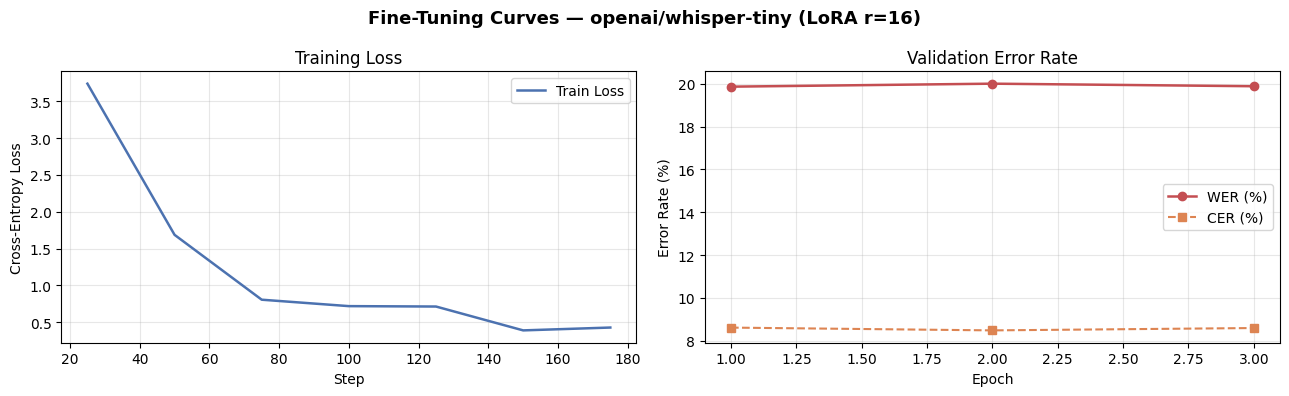

🏆 Best WER: 19.87% at epoch 1.0
   Best CER: 8.48%


In [ ]:
log_history = trainer.state.log_history

# Separate training-loss entries from evaluation-metric entries
train_logs = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs  = [e for e in log_history if "eval_wer" in e]

train_steps  = [e["step"]           for e in train_logs]
train_losses = [e["loss"]           for e in train_logs]
eval_epochs  = [e.get("epoch", i+1) for i, e in enumerate(eval_logs)]
eval_wers    = [e["eval_wer"]       for e in eval_logs]
eval_cers    = [e.get("eval_cer")   for e in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Fine-Tuning Curves — {MODEL_NAME} (LoRA r={LORA_R})", fontsize=13, fontweight="bold")

# --- Training loss ---
ax1 = axes[0]
ax1.plot(train_steps, train_losses, color="#4C72B0", linewidth=1.8, label="Train Loss")
ax1.set_xlabel("Step")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Training Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Eval WER (and optional CER) ---
ax2 = axes[1]
ax2.plot(eval_epochs, eval_wers, "o-", color="#C44E52", linewidth=1.8, label="WER (%)")
if any(v is not None for v in eval_cers):
    ax2.plot(eval_epochs, eval_cers, "s--", color="#DD8452", linewidth=1.5, label="CER (%)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Error Rate (%)")
ax2.set_title("Validation Error Rate")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

if eval_wers:
    best_epoch = eval_epochs[eval_wers.index(min(eval_wers))]
    print(f"🏆 Best WER: {min(eval_wers):.2f}% at epoch {best_epoch}")
    if any(v is not None for v in eval_cers):
        print(f"   Best CER: {min(v for v in eval_cers if v is not None):.2f}%")

---
## 🏁 Step 9: Evaluate, Export & Sample Inference

In [ ]:
print("Evaluating fine-tuned model on the held-out evaluation set…")
results = trainer.evaluate()
print(f"✅ Final Validation WER : {results.get('eval_wer', 'N/A')}%")
if "eval_cer" in results:
    print(f"✅ Final Validation CER : {results.get('eval_cer', 'N/A')}%")

# ── Save model weights for deployment into VoiceDrop ──────────────────────────
model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)
print(f"✅ Model and processor saved to '{SAVE_DIR}'")

# ── Reference vs Prediction side-by-side table ────────────────────────────────
print("\n" + "─" * 80)
print("📋 Sample Inference — Reference vs. Prediction (first 5 eval samples)")
print("─" * 80)

model.eval()
for idx in range(min(5, len(eval_data))):
    sample = eval_data[idx]
    input_features = torch.tensor(
        np.array([sample["input_features"]], dtype=np.float32)
    ).to(device)

    # Build attention mask to fix 'pad token == eos token' warning
    attention_mask = torch.ones(input_features.shape[:2], dtype=torch.long, device=device)

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features=input_features,
            attention_mask=attention_mask,
            max_new_tokens=GEN_MAX_LEN,
        )

    prediction = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0].strip()

    # Recover reference label
    ref_ids = [t for t in sample["labels"] if t != -100]
    reference = tokenizer.decode(ref_ids, skip_special_tokens=True).strip()

    print(f"[{idx+1}] REF  : {reference}")
    print(f"    PRED : {prediction}")
    print()

print("─" * 80)

Evaluating fine-tuned model on the held-out evaluation set…


Training Loss,Validation Loss,Epoch,Wer,Cer
0.426709,0.566901,3,19.870000,8.610000


✅ Final Validation WER : 19.87%
✅ Final Validation CER : 8.61%
✅ Model and processor saved to './whisper_finetuned_delivery'

────────────────────────────────────────────────────────────────────────────────
📋 Sample Inference — Reference vs. Prediction (first 5 eval samples)
────────────────────────────────────────────────────────────────────────────────


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] REF  : when you call someone who is thousands of miles away you are using a satellite
    PRED : when you call someone who is thousands of miles away you're using a satellite



...

[2] REF  : now widely available throughout the archipelago javanese cuisine features an array of simply seasoned dishes the predominant flavorings the javanese favor being peanuts chillies sugar especially javanese coconut sugar and various aromatic spices
    PRED : now widely available throughout the archipelago jaffini's cuisines features in a ray of simply seasoned dishes the predominant flavorings the jaffini's favorite bay peanuts chilis sugar especially jaffini's coconut sugar and various aromatic spices



[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[3] REF  : the u.n. also hopes to finalize a fund to help countries affected by global warming to cope with the impacts
    PRED : the UN also hopes to finalize a fund to help countries affected by global warming to cope with the impacts



[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[4] REF  : then lakkha singh took the lead in singing the bhajans
    PRED : then lock a sink to the lead and sink in the mushrooms

[5] REF  : the major religion in moldova is orthodox christian
    PRED : the major religion in wildova is orthodox christian

────────────────────────────────────────────────────────────────────────────────
